# SemRel Dataset — Data Exploration
**COS 760 Group Project**  
This notebook explores the **raw** SemRel dataset for **Afrikaans** before any preprocessing.
Data is loaded directly from the [SemRel/SemRel2024](https://huggingface.co/datasets/SemRel/SemRel2024) HuggingFace dataset.


## 1. Imports & Setup

In [1]:
!pip install pandas numpy matplotlib seaborn wordcloud scipy datasets -q


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from collections import Counter

import re
import os
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

OUTPUT_DIR = './exploration_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LANGUAGES = ['afr']          # Afrikaans only
LANGUAGE_NAMES = {'afr': 'Afrikaans'}
SPLITS = ['train', 'dev', 'test']
COLORS = {'afr': '#4C72B0'}

print('Setup complete.')


Setup complete.


## 2. Load Raw Data

In [3]:
from datasets import load_dataset

data = {}
for lang in LANGUAGES:
    data[lang] = {}
    for split in SPLITS:
        try:
            dataset = load_dataset(
                'SemRel/SemRel2024',
                lang,
                split=split,
                trust_remote_code=True
            )
            data[lang][split] = dataset.to_pandas()
            print(f'Loaded {LANGUAGE_NAMES[lang]} {split}: {len(data[lang][split])} rows')
        except Exception as e:
            print(f'Could not load {lang} {split}: {e}')
print('\nDataset loading complete.')


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'SemRel/SemRel2024' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
Generating dev split: 100%|██████████| 375/375 [00:00<00:00, 30684.04 examples/s]
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'SemRel/SemRel2024' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Could not load afr train: Unknown split "train". Should be one of ['test', 'dev'].


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'SemRel/SemRel2024' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded Afrikaans dev: 375 rows
Loaded Afrikaans test: 375 rows

Dataset loading complete.


## 3. Dataset Size Overview

Dataset size per split (Afrikaans):


,Train,Dev,Test,Total
Language,,,,
Afrikaans,0,375,375,750


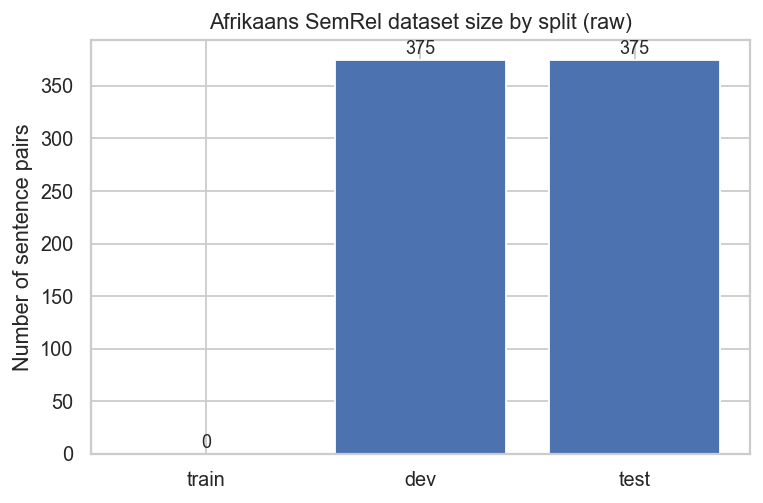

In [4]:
# Summary table
summary_rows = []
for lang in LANGUAGES:
    row = {'Language': LANGUAGE_NAMES[lang]}
    total = 0
    for split in SPLITS:
        n = len(data[lang][split]) if split in data[lang] else 0
        row[split.capitalize()] = n
        total += n
    row['Total'] = total
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print('Dataset size per split (Afrikaans):')
display(summary_df.set_index('Language'))

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
split_vals = [len(data['afr'][s]) if s in data['afr'] else 0 for s in SPLITS]
bars = ax.bar(SPLITS, split_vals, color='#4C72B0', edgecolor='white')
for bar, count in zip(bars, split_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(count), ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of sentence pairs')
ax.set_title('Afrikaans SemRel dataset size by split (raw)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/dataset_sizes.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Relatedness Score Distributions

In [5]:
# Distribution — train split
if 'train' in data['afr']:
    scores = data['afr']['train']['score']
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(scores, bins=25, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(scores.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {scores.mean():.3f}')
    ax.axvline(scores.median(), color='gray', linestyle=':', linewidth=1.2,
               label=f'Median: {scores.median():.3f}')
    ax.set_title('Afrikaans — relatedness score distribution (train, raw)')
    ax.set_xlabel('Relatedness score')
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/score_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()


In [6]:
# Descriptive statistics table
stats_rows = []
for lang in LANGUAGES:
    if 'train' not in data[lang]:
        continue
    scores = data[lang]['train']['score']
    stats_rows.append({
        'Language': LANGUAGE_NAMES[lang],
        'Min':    round(scores.min(), 4),
        'Max':    round(scores.max(), 4),
        'Mean':   round(scores.mean(), 4),
        'Median': round(scores.median(), 4),
        'Std':    round(scores.std(), 4),
        'Skewness': round(scores.skew(), 4)
    })

stats_df = pd.DataFrame(stats_rows)
print('Score statistics (train split):')
display(stats_df.set_index('Language'))

Score statistics (train split):


KeyError: "None of ['Language'] are in the columns"

In [ ]:
# KDE of scores across all splits
fig, ax = plt.subplots(figsize=(8, 4))
split_colors = {'train': '#4C72B0', 'dev': '#DD8452', 'test': '#55A868'}
for split in SPLITS:
    if split in data['afr']:
        data['afr'][split]['score'].plot.kde(
            ax=ax, label=split.capitalize(),
            color=split_colors[split], linewidth=2)
ax.set_xlabel('Relatedness score')
ax.set_ylabel('Density')
ax.set_title('Afrikaans — score density across splits (raw)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/score_kde_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Score Distribution Across Splits (Train / Dev / Test)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
split_colors = {'train': '#4C72B0', 'dev': '#DD8452', 'test': '#55A868'}

for j, split in enumerate(SPLITS):
    ax = axes[j]
    if split in data['afr']:
        scores = data['afr'][split]['score']
        ax.hist(scores, bins=20, color=split_colors[split], edgecolor='white', alpha=0.8)
        ax.set_title(f'Afrikaans — {split}', fontsize=10)
        ax.set_xlabel('Score')
        ax.set_ylabel('Count')
    else:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', va='center', color='gray')
        ax.set_title(f'Afrikaans — {split}', fontsize=10)

fig.suptitle('Afrikaans score distributions across splits (raw)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/score_splits_grid.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Sentence Length Analysis

In [ ]:
# Add word / char count columns
if 'train' in data['afr']:
    df = data['afr']['train']
    df['wc1'] = df['sentence1'].apply(lambda x: len(str(x).split()))
    df['wc2'] = df['sentence2'].apply(lambda x: len(str(x).split()))
    df['cc1'] = df['sentence1'].apply(len)
    df['cc2'] = df['sentence2'].apply(len)
    df['avg_wc'] = (df['wc1'] + df['wc2']) / 2

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Boxplot: S1 vs S2 word counts
    wc_data = []
    for col, label in [('wc1', 'Sentence 1'), ('wc2', 'Sentence 2')]:
        for val in df[col]:
            wc_data.append({'Sentence': label, 'Word count': val})
    wc_df = pd.DataFrame(wc_data)
    sns.boxplot(data=wc_df, x='Sentence', y='Word count', ax=axes[0],
                palette='muted', width=0.4)
    axes[0].set_title('Afrikaans — word count distribution (raw train)')
    axes[0].set_ylim(0, wc_df['Word count'].quantile(0.98))

    # Scatter: avg word count vs score
    axes[1].scatter(df['avg_wc'], df['score'], alpha=0.3, s=10, color='#4C72B0')
    axes[1].set_xlabel('Average word count of pair')
    axes[1].set_ylabel('Relatedness score')
    axes[1].set_title('Avg word count vs relatedness score (Afrikaans, raw)')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sentence_lengths.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nAfrikaans word counts (train):')
    print(f'  S1 avg={df["wc1"].mean():.1f} | S2 avg={df["wc2"].mean():.1f} | '
          f'Max S1={df["wc1"].max()} | Max S2={df["wc2"].max()}')


## 7. Score Bucket Analysis
Break scores into Low / Medium / High relatedness buckets.

In [ ]:
def assign_bucket(score):
    if score < 0.33:
        return 'Low (< 0.33)'
    elif score < 0.67:
        return 'Medium (0.33–0.67)'
    else:
        return 'High (> 0.67)'

if 'train' in data['afr']:
    df = data['afr']['train'].copy()
    df['bucket'] = df['score'].apply(assign_bucket)
    counts = df['bucket'].value_counts()

    bucket_colors = ['#E74C3C', '#F39C12', '#27AE60']
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bar chart
    axes[0].bar(counts.index, counts.values, color=bucket_colors, edgecolor='white')
    for i, (label, val) in enumerate(counts.items()):
        axes[0].text(i, val + 1, f'{val}\n({100*val/len(df):.1f}%)',
                     ha='center', fontsize=9)
    axes[0].set_title('Afrikaans — score bucket counts (raw train)')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=10)

    # Pie chart
    axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                colors=bucket_colors, startangle=90, textprops={'fontsize': 9})
    axes[1].set_title('Afrikaans — score bucket breakdown')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/score_buckets.png', dpi=150, bbox_inches='tight')
    plt.show()
    display(counts.rename('Count').to_frame())


## 8. Top Frequent Words
Useful for understanding Afrikaans vocabulary before preprocessing (stopwords still present).

In [ ]:
def get_top_words(df, n=20):
    all_text = ' '.join(
        df['sentence1'].tolist() + df['sentence2'].tolist()
    ).lower()
    words = re.findall(r'\b[a-zA-ZÀ-ÿ]{2,}\b', all_text)
    return Counter(words).most_common(n)

if 'train' in data['afr']:
    top_words = get_top_words(data['afr']['train'], n=20)
    words, counts = zip(*top_words)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(words[::-1], counts[::-1], color='#4C72B0', edgecolor='white')
    ax.set_title('Afrikaans — top 20 words before preprocessing (train)')
    ax.set_xlabel('Frequency')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/top_words.png', dpi=150, bbox_inches='tight')
    plt.show()


## 9. Sample Pairs by Score Range
Qualitatively inspect what high, medium, and low relatedness pairs look like.

In [ ]:
def show_sample_pairs(score_min, score_max, n=3, split='train'):
    if split not in data['afr']:
        print(f'No {split} data for Afrikaans')
        return
    df = data['afr'][split]
    subset = df[(df['score'] >= score_min) & (df['score'] <= score_max)].sample(
        min(n, len(df)), random_state=42
    )
    print(f'\nAfrikaans (raw) — score range [{score_min:.2f}, {score_max:.2f}]:')
    print('-' * 70)
    for _, row in subset.iterrows():
        print(f'  Score:      {row["score"]:.4f}')
        print(f'  Sentence 1: {row["sentence1"]}')
        print(f'  Sentence 2: {row["sentence2"]}')
        print()

show_sample_pairs(0.8, 1.0, n=3)   # High relatedness
show_sample_pairs(0.4, 0.6, n=3)   # Medium
show_sample_pairs(0.0, 0.2, n=3)   # Low


## 10. Correlation: Word Count vs Score

In [ ]:
print('Spearman correlation — average word count vs relatedness score (raw train):\n')
if 'train' in data['afr']:
    df = data['afr']['train']
    if 'avg_wc' not in df.columns:
        df['avg_wc'] = (df['sentence1'].apply(lambda x: len(str(x).split())) +
                        df['sentence2'].apply(lambda x: len(str(x).split()))) / 2
    corr, pval = stats.spearmanr(df['avg_wc'], df['score'])
    print(f'  Afrikaans: ρ = {corr:.4f}  (p = {pval:.4f})')


## 11. Score Distribution Across Splits (Boxplot)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

box_data = []
box_labels = []
split_colors_list = {'train': '#4C72B0', 'dev': '#DD8452', 'test': '#55A868'}
colors_list = []

for split in SPLITS:
    if split in data['afr']:
        box_data.append(data['afr'][split]['score'].values)
        box_labels.append(split.capitalize())
        colors_list.append(split_colors_list[split])

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Relatedness score')
ax.set_title('Afrikaans — score distribution across splits (raw)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cross_language_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Missing / Duplicate Check

In [ ]:
print('Data quality check (raw Afrikaans data):\n')
print(f'{"Split":<8} {"Nulls":<10} {"Duplicates":<12} {"Rows"}')
print('-' * 40)

for split in SPLITS:
    if split not in data['afr']:
        continue
    df = data['afr'][split]
    nulls = df[['sentence1', 'sentence2', 'score']].isnull().sum().sum()
    dupes = df.duplicated(subset=['sentence1', 'sentence2']).sum()
    print(f'{split:<8} {nulls:<10} {dupes:<12} {len(df)}')


## 13. Summary Findings
Key observations to include in the report.

In [ ]:
print('KEY OBSERVATIONS FOR REPORT — Afrikaans (raw, before preprocessing)')
print('=' * 60)

if 'train' in data['afr']:
    df = data['afr']['train']
    scores = df['score']
    print(f'\nAfrikaans:')
    print(f'  Train size   : {len(df)} pairs')
    print(f'  Score mean   : {scores.mean():.4f}')
    print(f'  Score std    : {scores.std():.4f}')
    print(f'  Score skew   : {scores.skew():.4f} '
          f'({"right-skewed" if scores.skew() > 0 else "left-skewed"})')
    low  = (scores < 0.33).sum()
    mid  = ((scores >= 0.33) & (scores < 0.67)).sum()
    high = (scores >= 0.67).sum()
    print(f'  Low / Mid / High: {low} / {mid} / {high} '
          f'({100*low/len(df):.0f}% / {100*mid/len(df):.0f}% / {100*high/len(df):.0f}%)')

print('\nAll exploration plots saved to:', OUTPUT_DIR)
